In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import sys
sys.path.insert(0, '../')
from ultility.metrics import rolling_std_vol
from ultility.models_garch import garch_forecast_fixed_params
from ultility.models_lstm_baseline import train_lstm_baseline, predict_lstm_baseline_rolling
from ultility.models_transformer import train_transformer
from ultility.lstmgarch import LSTMGARCH
from ultility.transformer_garch import TransformerGARCH
from ultility.eval_vol import save_and_plot
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

In [2]:
path = '../dataset/VN30_dataset_from_2019.csv'
df = pd.read_csv(path)
df['time'] = pd.to_datetime(df['time'], format='mixed', dayfirst=True, errors='coerce')
df_2020 = df[df['time'].dt.year >= 2020]
stocks_returns = (
    df_2020.sort_values('time').groupby('time')
    .apply(lambda x: np.average(x['return_1d'], weights=x['Market Capital (Bn VND)'] / x['Market Capital (Bn VND)'].sum()))
    .dropna()
)
stocks_returns = stocks_returns.to_frame(name='stocks_return')
stocks_returns['stocks_return'] = stocks_returns['stocks_return'] * 100
datasets = {}
datasets['Stock returns'] = stocks_returns['stocks_return']
df_vn30 = pd.read_csv('../dataset/VN30_INDEX.csv')
df_vn30['time'] = pd.to_datetime(df_vn30['time'], format='mixed', dayfirst=True, errors='coerce')
df_vn30_2020 = df_vn30[df_vn30['time'].dt.year >= 2020].copy()
datasets['VN30 Index'] = df_vn30_2020.set_index('time')['return_1_day']
df_vn = pd.read_csv('../dataset/VN_INDEX.csv')
df_vn['time'] = pd.to_datetime(df_vn['time'], format='mixed', dayfirst=True, errors='coerce')
df_vn_2020 = df_vn[df_vn['time'].dt.year >= 2020].copy()
datasets['VN Index'] = (df_vn_2020.set_index('time')['return_1_day'] * 100)
for file in ['DAX_40.csv', 'EuroNext_100.csv', 'IBEX_35.csv', 'KOSPI_index.csv', 'SMI.csv', 'snp500.csv', 'Nikkei_225.csv']:
    df_temp = pd.read_csv(f'../dataset/{file}')
    if 'Date' in df_temp.columns:
        df_temp.rename(columns={'Date': 'time'}, inplace=True)
    df_temp['time'] = pd.to_datetime(df_temp['time'], format='mixed', dayfirst=False, errors='coerce')
    df_temp = df_temp.dropna(subset=['time'])
    df_temp_2020 = df_temp[df_temp['time'].dt.year >= 2020].copy()
    if 'close' in df_temp_2020.columns:
        returns = np.log(df_temp_2020['close'] / df_temp_2020['close'].shift(1)).fillna(0) * 100
        datasets[file.replace('.csv', '')] = pd.Series(returns.values, index=df_temp_2020['time'].values)
data = {
    'Dataset': ['Stock returns', 'VN30 Index', 'VN Index', 'DAX_40', 'EuroNext_100', 'IBEX_35', 'KOSPI_index', 'SMI', 'snp500', 'Nikkei_225'],
    'Train': [946, 886, 949, 1066, 769, 962, 979, 1055, 1054, 1021],
    'Val': [184, 279, 209, 276, 154, 159, 161, 168, 229, 189],
    'Test': [368, 334, 341, 186, 615, 421, 331, 287, 225, 255],
}
split_df = pd.DataFrame(data).set_index('Dataset')[['Train', 'Val', 'Test']]

In [3]:
nu_dict = {}
for ds, series in datasets.items():
    tr = int(split_df.loc[ds, 'Train'])
    train_data = series.iloc[:tr].values if hasattr(series, 'iloc') else series[:tr]
    if len(train_data) < 20:
        nu_dict[ds] = 8.0
        continue
    nu, loc, scale = stats.t.fit(train_data)
    nu_dict[ds] = max(nu, 4.0)
print('Nu values:', nu_dict)

Nu values: {'Stock returns': 4.0, 'VN30 Index': 4.0, 'VN Index': 4.0, 'DAX_40': 4.0, 'EuroNext_100': 4.0, 'IBEX_35': 4.0, 'KOSPI_index': np.float64(4.3570738396768895), 'SMI': 4.0, 'snp500': 4.0, 'Nikkei_225': np.float64(5.412576006188138)}


In [4]:
seq_len = 60

def seq_xy(x, s=60):
    x = np.asarray(x, dtype=np.float32)
    if len(x) <= s:
        return np.empty((0, s), np.float32), np.empty((0,), np.float32)
    return np.stack([x[i:i+s] for i in range(len(x)-s)]), x[s:]

def fit_torch(model, x, s=60, epochs=5, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    x = np.asarray(x, dtype=np.float32)
    if len(x) <= s + 1:
        return model.to(device)
    mu, sd = x.mean(), x.std() + 1e-8
    z = (x - mu) / sd
    X, y = seq_xy(z, s)
    ds = torch.utils.data.TensorDataset(torch.tensor(X), torch.tensor(y))
    dl = torch.utils.data.DataLoader(ds, batch_size=32, shuffle=True)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
    model._mu, model._sd = mu, sd
    return model

def pred_torch(model, train, test, s=60):
    device = next(model.parameters()).device
    hist = np.asarray(train, dtype=np.float32).tolist()
    out = []
    model.eval()
    with torch.no_grad():
        for x in np.asarray(test, dtype=np.float32):
            if len(hist) < s:
                out.append(np.nan)
                hist.append(x)
                continue
            z = (np.asarray(hist[-s:], np.float32) - model._mu) / model._sd
            xb = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
            p = model(xb).detach().cpu().numpy().reshape(-1)[0]
            out.append(float(p * model._sd + model._mu))
            hist.append(float(x))
    return np.abs(np.asarray(out, dtype=np.float32))

predictions = {'GARCH': {}, 'GJR-GARCH': {}, 'LSTM': {}, 'Transformer': {}, 'LSTMGARCH': {}, 'TransformerGARCH': {}}
for ds, series in datasets.items():
    data = series.values if hasattr(series, 'values') else np.asarray(series)
    tr, va, te = map(int, split_df.loc[ds, ['Train', 'Val', 'Test']])
    train_set, test_set = data[:tr+va], data[tr+va:tr+va+te]
    print(f'Training {ds}...')
    predictions['GARCH'][ds] = garch_forecast_fixed_params(train_set, test_set, 'GARCH')
    predictions['GJR-GARCH'][ds] = garch_forecast_fixed_params(train_set, test_set, 'GJR-GARCH')
    try:
        m, scaler, _, _ = train_lstm_baseline(train_set, seq_len=seq_len, epochs=5, batch_size=32)
        predictions['LSTM'][ds] = predict_lstm_baseline_rolling(m, train_set, test_set, seq_len, scaler)
    except:
        predictions['LSTM'][ds] = rolling_std_vol(test_set, seq_len)
    try:
        predictions['Transformer'][ds] = np.abs(train_transformer(train_set, test_set, seq_len=seq_len, epochs=5))
    except:
        predictions['Transformer'][ds] = rolling_std_vol(test_set, seq_len)
    try:
        m = fit_torch(LSTMGARCH(), train_set, seq_len, epochs=5)
        predictions['LSTMGARCH'][ds] = pred_torch(m, train_set, test_set, seq_len)
    except:
        predictions['LSTMGARCH'][ds] = rolling_std_vol(test_set, seq_len)
    try:
        m = fit_torch(TransformerGARCH(), train_set, seq_len, epochs=5)
        predictions['TransformerGARCH'][ds] = pred_torch(m, train_set, test_set, seq_len)
    except:
        predictions['TransformerGARCH'][ds] = rolling_std_vol(test_set, seq_len)

Training Stock returns...
Training VN30 Index...
Training VN Index...
Training DAX_40...
Training EuroNext_100...
Training IBEX_35...
Training KOSPI_index...
Training SMI...
Training snp500...
Training Nikkei_225...


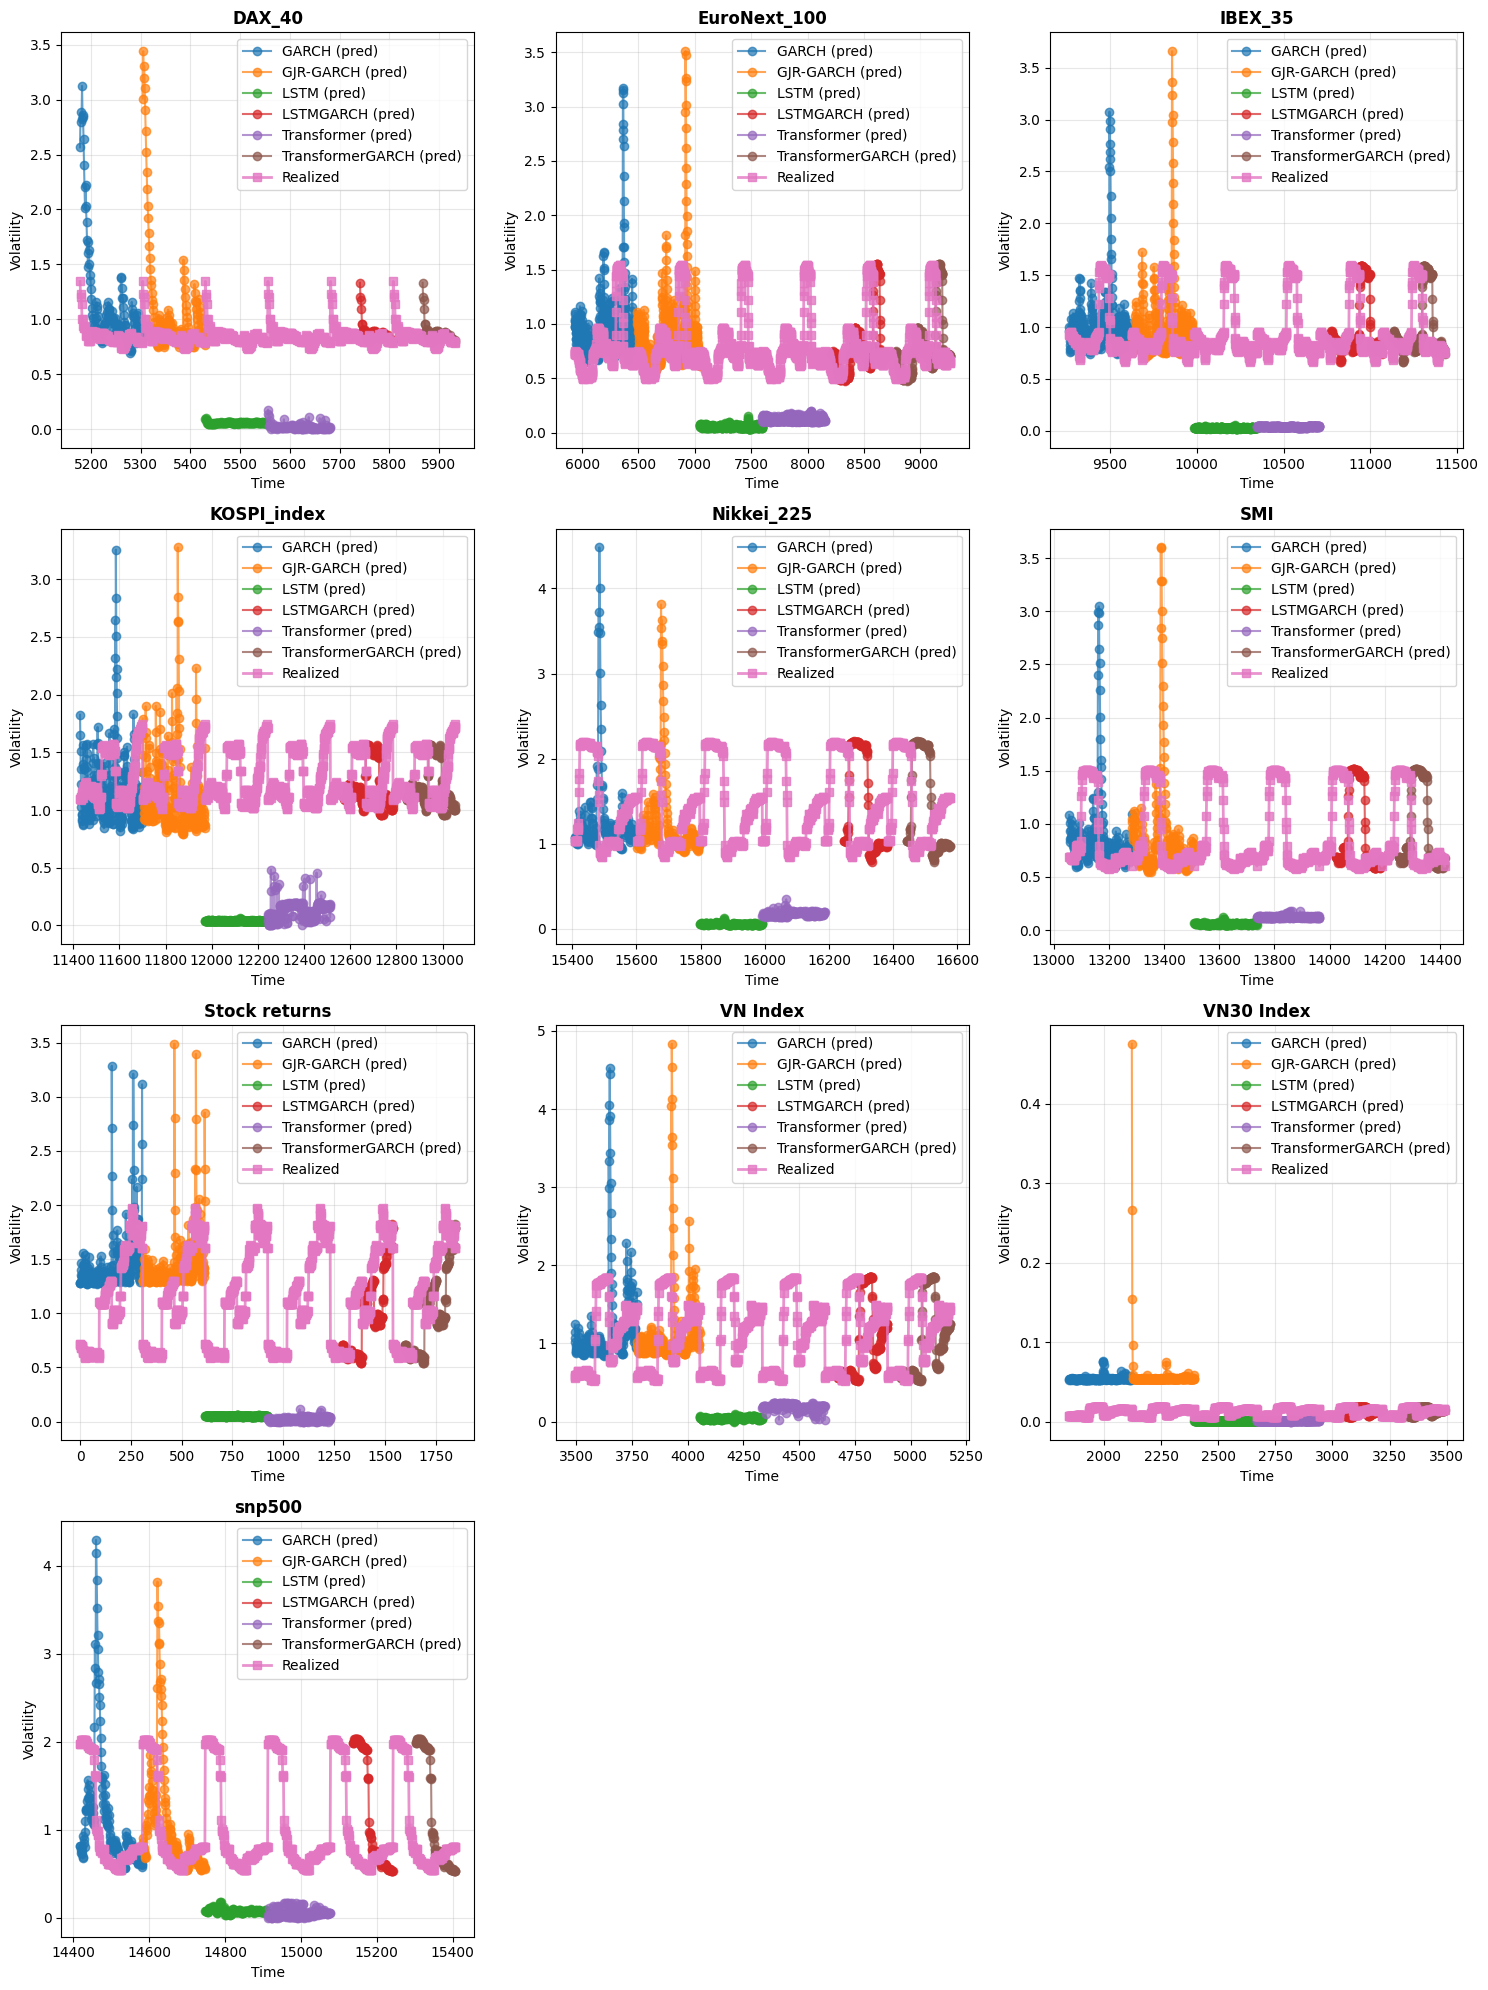

Predictions saved to ../output/predicts.csv
Results saved to ../output/models_results.csv
          Dataset             Model       MSE          QLIKE  \
0   Stock returns             GARCH  0.272507       1.433867   
1   Stock returns         GJR-GARCH  0.277834       1.436959   
2   Stock returns              LSTM  1.410826     624.368761   
3   Stock returns       Transformer  1.468890  292862.214017   
4   Stock returns         LSTMGARCH       NaN            NaN   
5   Stock returns  TransformerGARCH       NaN            NaN   
6      VN30 Index             GARCH  0.001751      -5.781297   
7      VN30 Index         GJR-GARCH  0.002894      -5.732112   
8      VN30 Index              LSTM  0.000157     401.648667   
9      VN30 Index       Transformer  0.000151     850.834770   
10     VN30 Index         LSTMGARCH       NaN            NaN   
11     VN30 Index  TransformerGARCH       NaN            NaN   
12       VN Index             GARCH  0.513814       1.601190   
13       VN In

In [5]:
preds_df, results_df = save_and_plot(datasets, split_df, predictions, nu_dict, seq_len=seq_len, output_dir='../output')
print('Predictions saved to ../output/predicts.csv')
print('Results saved to ../output/models_results.csv')
print(results_df)